# Apply to Rows

`apply_to_rows` lets you:
1. **Filter** rows matching a condition
2. **Transform** only those rows
3. **Merge** them back with the rest

This is simpler than `branch` when you just need to transform a subset of rows.

In [1]:
import polars as pl

from nebula import TransformerPipeline
from nebula.storage import nebula_storage as ns
from nebula.transformers import (
    AddLiterals,
    Filter,
    RenameColumns,
    SelectColumns,
)

## Sample Data

In [2]:
# Main orders dataframe
orders_df = pl.DataFrame({
    "order_id": [1, 2, 3, 4, 5, 6],
    "customer": ["Alice", "Bob", "Charlie", "Diana", "Eve", "Frank"],
    "amount": [150.0, 80.0, 320.0, 45.0, 200.0, 95.0],
    "status": ["completed", "pending", "completed", "pending", "completed", "cancelled"],
})

print("Orders:")
print(orders_df)

Orders:
shape: (6, 4)
┌──────────┬──────────┬────────┬───────────┐
│ order_id ┆ customer ┆ amount ┆ status    │
│ ---      ┆ ---      ┆ ---    ┆ ---       │
│ i64      ┆ str      ┆ f64    ┆ str       │
╞══════════╪══════════╪════════╪═══════════╡
│ 1        ┆ Alice    ┆ 150.0  ┆ completed │
│ 2        ┆ Bob      ┆ 80.0   ┆ pending   │
│ 3        ┆ Charlie  ┆ 320.0  ┆ completed │
│ 4        ┆ Diana    ┆ 45.0   ┆ pending   │
│ 5        ┆ Eve      ┆ 200.0  ┆ completed │
│ 6        ┆ Frank    ┆ 95.0   ┆ cancelled │
└──────────┴──────────┴────────┴───────────┘


### 2.1 Basic Apply to Rows

Apply a discount only to high-value orders.

In [3]:
pipe_apply_basic = TransformerPipeline(
    [
        # These transformers apply ONLY to rows where amount >= 200
        AddLiterals(data=[{"alias": "discount", "value": 0.1}]),
    ],
    apply_to_rows={
        "input_col": "amount",
        "operator": "ge",
        "value": 200,
    },
    otherwise=[
        # Rows where amount < 200 get no discount
        AddLiterals(data=[{"alias": "discount", "value": 0.0}]),
    ],
    name="Apply Discount to High-Value",
    allow_missing_columns=True,
)

result = pipe_apply_basic.run(orders_df)
result.sort("order_id")

2026-03-09 12:45:23,789 | [INFO]: Starting pipeline 'Apply Discount to High-Value' 
2026-03-09 12:45:23,790 | [INFO]: Entering apply_to_rows 
2026-03-09 12:45:23,836 | [INFO]: Running 'AddLiterals' ... 
2026-03-09 12:45:23,837 | [INFO]: Completed 'AddLiterals' in 0.0s 
2026-03-09 12:45:23,838 | [INFO]: Running 'AddLiterals' ... 
2026-03-09 12:45:23,838 | [INFO]: Completed 'AddLiterals' in 0.0s 
2026-03-09 12:45:23,840 | [INFO]: Pipeline 'Apply Discount to High-Value' completed in 0.1s 


order_id,customer,amount,status,discount
i64,str,f64,str,f64
1,"""Alice""",150.0,"""completed""",0.0
2,"""Bob""",80.0,"""pending""",0.0
3,"""Charlie""",320.0,"""completed""",0.1
4,"""Diana""",45.0,"""pending""",0.0
5,"""Eve""",200.0,"""completed""",0.1
6,"""Frank""",95.0,"""cancelled""",0.0


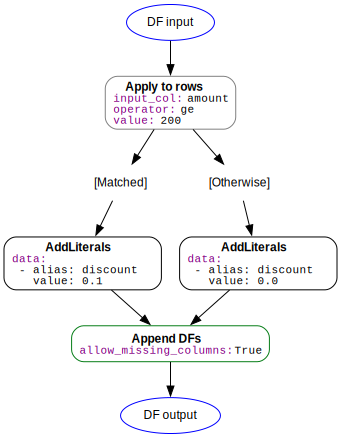

In [4]:
pipe_apply_basic.plot(add_params=True)

### 2.2 Apply to Rows with Column Comparison

You can compare columns to each other using `comparison_column` instead of `value`.

In [5]:
# Add a threshold column
orders_with_threshold = orders_df.with_columns(
    pl.lit(100.0).alias("threshold")
)

pipe_apply_col_compare = TransformerPipeline(
    [
        AddLiterals(data=[{"alias": "above_threshold", "value": True}]),
    ],
    apply_to_rows={
        "input_col": "amount",
        "operator": "gt",
        "comparison_column": "threshold",  # Compare amount > threshold
    },
    otherwise=[
        AddLiterals(data=[{"alias": "above_threshold", "value": False}]),
    ],
    name="Compare to Threshold",
)

result = pipe_apply_col_compare.run(orders_with_threshold)
result.sort("order_id")

2026-03-09 12:45:24,314 | [INFO]: Starting pipeline 'Compare to Threshold' 
2026-03-09 12:45:24,315 | [INFO]: Entering apply_to_rows 
2026-03-09 12:45:24,317 | [INFO]: Running 'AddLiterals' ... 
2026-03-09 12:45:24,318 | [INFO]: Completed 'AddLiterals' in 0.0s 
2026-03-09 12:45:24,318 | [INFO]: Running 'AddLiterals' ... 
2026-03-09 12:45:24,319 | [INFO]: Completed 'AddLiterals' in 0.0s 
2026-03-09 12:45:24,320 | [INFO]: Pipeline 'Compare to Threshold' completed in 0.0s 


order_id,customer,amount,status,threshold,above_threshold
i64,str,f64,str,f64,bool
1,"""Alice""",150.0,"""completed""",100.0,true
2,"""Bob""",80.0,"""pending""",100.0,false
3,"""Charlie""",320.0,"""completed""",100.0,true
4,"""Diana""",45.0,"""pending""",100.0,false
5,"""Eve""",200.0,"""completed""",100.0,true
6,"""Frank""",95.0,"""cancelled""",100.0,false


### 2.3 Apply to Rows → Dead-End

Process matching rows but don't merge them back (remove them from output).

In [6]:
def log_cancelled(df):
    """Log cancelled orders (side effect)."""
    print(f"⚠️ Found {len(df)} cancelled orders")
    return df


pipe_apply_deadend = TransformerPipeline(
    [
        log_cancelled,
    ],
    apply_to_rows={
        "input_col": "status",
        "operator": "eq",
        "value": "cancelled",
        "dead-end": True,  # Don't merge back (removes cancelled)
    },
    name="Remove Cancelled Orders",
)

result = pipe_apply_deadend.run(orders_df)
print(f"\nOutput excludes cancelled ({len(result)} rows):")
result

2026-03-09 12:45:24,336 | [INFO]: Starting pipeline 'Remove Cancelled Orders' 
2026-03-09 12:45:24,341 | [INFO]: Entering apply_to_rows 
2026-03-09 12:45:24,341 | [INFO]: Running 'log_cancelled' ... 
2026-03-09 12:45:24,341 | [INFO]: Completed 'log_cancelled' in 0.0s 
2026-03-09 12:45:24,345 | [INFO]: Pipeline 'Remove Cancelled Orders' completed in 0.0s 


⚠️ Found 1 cancelled orders

Output excludes cancelled (5 rows):


order_id,customer,amount,status
i64,str,f64,str
1,"""Alice""",150.0,"""completed"""
2,"""Bob""",80.0,"""pending"""
3,"""Charlie""",320.0,"""completed"""
4,"""Diana""",45.0,"""pending"""
5,"""Eve""",200.0,"""completed"""


### 2.4 Apply to Rows — Available Operators

| Operator | Description | Value Type |
|----------|-------------|------------|
| `eq`, `ne` | Equal / Not equal | Any |
| `lt`, `le`, `gt`, `ge` | Comparisons | Comparable |
| `is_null`, `is_not_null` | Null checks | (no value) |
| `is_nan`, `is_not_nan` | NaN checks | (no value) |
| `is_in`, `is_not_in` | Set membership | List/Set |
| `is_between` | Range (inclusive) | [lower, upper] |
| `contains`, `starts_with`, `ends_with` | String matching | String |

In [7]:
# Example: is_in operator
pipe_apply_isin = TransformerPipeline(
    [
        AddLiterals(data=[{"alias": "needs_action", "value": True}]),
    ],
    apply_to_rows={
        "input_col": "status",
        "operator": "is_in",
        "value": ["pending", "cancelled"],  # List of values
    },
    otherwise=[
        AddLiterals(data=[{"alias": "needs_action", "value": False}]),
    ],
    name="Flag Actionable Orders",
)

pipe_apply_isin.run(orders_df).sort("order_id")

2026-03-09 12:45:24,355 | [INFO]: Starting pipeline 'Flag Actionable Orders' 
2026-03-09 12:45:24,355 | [INFO]: Entering apply_to_rows 
2026-03-09 12:45:24,355 | [INFO]: Running 'AddLiterals' ... 
2026-03-09 12:45:24,355 | [INFO]: Completed 'AddLiterals' in 0.0s 
2026-03-09 12:45:24,360 | [INFO]: Running 'AddLiterals' ... 
2026-03-09 12:45:24,360 | [INFO]: Completed 'AddLiterals' in 0.0s 
2026-03-09 12:45:24,360 | [INFO]: Pipeline 'Flag Actionable Orders' completed in 0.0s 


order_id,customer,amount,status,needs_action
i64,str,f64,str,bool
1,"""Alice""",150.0,"""completed""",false
2,"""Bob""",80.0,"""pending""",true
3,"""Charlie""",320.0,"""completed""",false
4,"""Diana""",45.0,"""pending""",true
5,"""Eve""",200.0,"""completed""",false
6,"""Frank""",95.0,"""cancelled""",true


---
## Summary

| Config Key | Description |
|------------|-------------|
| `input_col` | Column to filter on |
| `operator` | Comparison operator (see table above) |
| `value` | Value to compare against |
| `comparison_column` | Compare to another column (instead of value) |
| `dead-end` | If True, matching rows are removed |
| `skip_if_empty` | Skip if no rows match |
| `skip` / `perform` | Conditionally disable |

**Next notebook:** Skip Options — conditionally disable transformers, branches, or pipelines